In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Task 1: Load the dataset 
df = pd.read_csv('Coffee.csv') 

print("--- First 20 Rows ---")
display(df.head(20))

print("\n--- Dataset Info ---")
    print(df.info())
print(f"\nShape: {df.shape}")

df['Date'] = pd.to_datetime(df['Date'])
if df['Sales'].dtype == 'object':
    df['Sales'] = pd.to_numeric(df['Sales'], errors='coerce')

--- First 20 Rows ---


,Area Code,Date,Market,Market Size,Product,Product Line,Product Type,State,Type,Budget COGS,Budget Margin,Budget Profit,Budget Sales,COGS,Inventory,Margin,Marketing,Profit,Sales,Total Expenses
0,719,40909,Central,Major Market,Amaretto,Beans,Coffee,Colorado,Regular,90,130,100,220,89,777,130,24,94,219,36
1,970,40909,Central,Major Market,Colombian,Beans,Coffee,Colorado,Regular,80,110,80,190,83,623,107,27,68,190,39
2,970,40909,Central,Major Market,Decaf Irish Cream,Beans,Coffee,Colorado,Decaf,100,140,110,240,95,821,139,26,101,234,38
3,303,40909,Central,Major Market,Green Tea,Leaves,Tea,Colorado,Regular,30,50,30,80,44,623,56,14,30,100,26
4,303,40909,Central,Major Market,Caffe Mocha,Beans,Espresso,Colorado,Regular,60,90,70,150,54,456,80,15,54,134,26
5,720,40909,Central,Major Market,Decaf Espresso,Beans,Espresso,Colorado,Decaf,80,130,80,210,72,558,108,23,53,180,55
6,970,40909,Central,Major Market,Chamomile,Leaves,Herbal Tea,Colorado,Decaf,140,160,110,300,170,1091,171,47,99,341,72
7,719,40909,Central,Major Market,Lemon,Leaves,Herbal Tea,Colorado,Decaf,50,80,20,130,63,435,87,57,0,150,87
8,970,40909,Central,Major Market,Mint,Leaves,Herbal Tea,Colorado,Decaf,50,70,40,120,60,336,80,19,33,140,47
9,719,40909,Central,Major Market,Darjeeling,Leaves,Tea,Colorado,Regular,40,70,20,110,58,338,72,22,17,130,55



--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4248 entries, 0 to 4247
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Area Code       4248 non-null   int64 
 1   Date            4248 non-null   int64 
 2   Market          4248 non-null   object
 3   Market Size     4248 non-null   object
 4   Product         4248 non-null   object
 5   Product Line    4248 non-null   object
 6   Product Type    4248 non-null   object
 7   State           4248 non-null   object
 8   Type            4248 non-null   object
 9   Budget COGS     4248 non-null   int64 
 10  Budget Margin   4248 non-null   int64 
 11  Budget Profit   4248 non-null   int64 
 12  Budget Sales    4248 non-null   int64 
 13  COGS            4248 non-null   int64 
 14  Inventory       4248 non-null   int64 
 15  Margin          4248 non-null   int64 
 16  Marketing       4248 non-null   int64 
 17  Profit          4248 non-null 

In [22]:
print(f"Duplicates before: {df.duplicated().sum()}")
df = df.drop_duplicates()
print(f"Shape after duplicates: {df.shape}")


df_cleaned = df.copy()

num_cols = df_cleaned.select_dtypes(include=[np.number]).columns
df_cleaned[num_cols] = df_cleaned[num_cols].fillna(df_cleaned[num_cols].mean())

cat_cols = df_cleaned.select_dtypes(include=['object']).columns
for col in cat_cols:
    df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].mode()[0])

print("\nMissing values handled!")

Duplicates before: 0
Shape after duplicates: (4248, 20)

Missing values handled!


In [23]:

if 'Area Code' in df_cleaned.columns:
    df_cleaned = df_cleaned.drop(['Area Code'], axis=1)
print(f"Final Columns: {df_cleaned.columns.tolist()}")


Final Columns: ['Date', 'Market', 'Market Size', 'Product', 'Product Line', 'Product Type', 'State', 'Type', 'Budget COGS', 'Budget Margin', 'Budget Profit', 'Budget Sales', 'COGS', 'Inventory', 'Margin', 'Marketing', 'Profit', 'Sales', 'Total Expenses']


In [24]:
bins = [0, 250, 600, df_cleaned['Sales'].max()]
labels = ['Low', 'Medium', 'High']
df_cleaned['Sales_Category'] = pd.cut(df_cleaned['Sales'], bins=bins, labels=labels)
print("\nSales Category Counts:")
print(df_cleaned['Sales_Category'].value_counts())


Sales Category Counts:
Sales_Category
Low       3322
Medium     776
High       150
Name: count, dtype: int64


In [25]:
# Task 6: 
top_prod = df_cleaned.groupby('Product')['Profit'].sum().idxmax()
print(f"Top Profitable Product: {top_prod}")

loss_state = df_cleaned.groupby('State')['Profit'].sum().idxmin()
print(f"State with Highest Loss: {loss_state}")

loss_making = df_cleaned[df_cleaned['Profit'] < 0]
print("\n--- Top Loss Making Records ---")
display(loss_making[['Product', 'Profit']].head())

Top Profitable Product: Colombian
State with Highest Loss: New Mexico

--- Top Loss Making Records ---


,Product,Profit
31,Green Tea,-4
34,Chamomile,-11
35,Lemon,-39
37,Earl Grey,-9
75,Caffe Mocha,-23


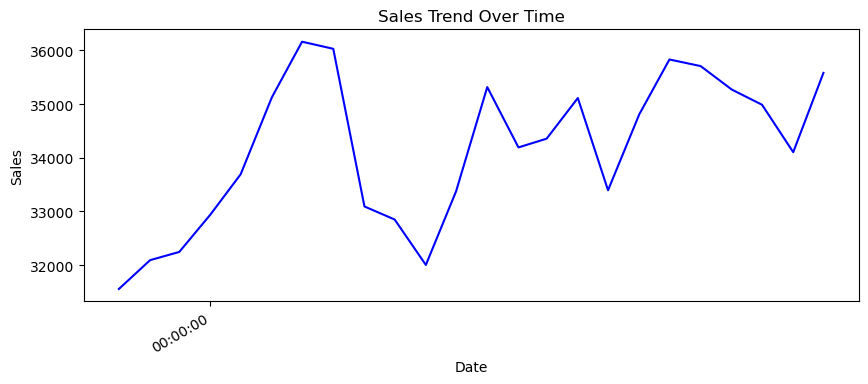

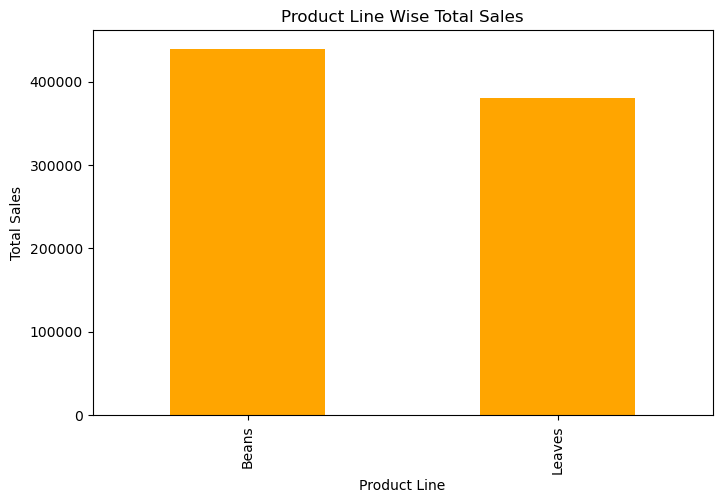

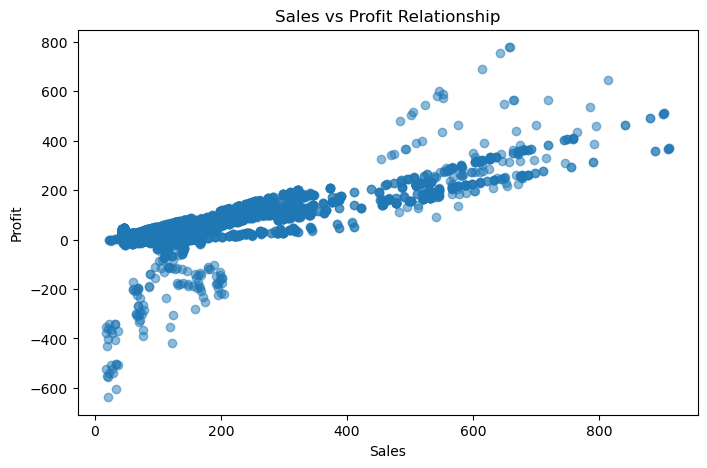

In [26]:
plt.figure(figsize=(10,4))
df_cleaned.groupby('Date')['Sales'].sum().plot(kind='line', color='blue')
plt.title('Sales Trend Over Time'); plt.xlabel('Date'); plt.ylabel('Sales')
plt.show()

plt.figure(figsize=(8,5))
df_cleaned.groupby('Product Line')['Sales'].sum().plot(kind='bar', color='orange')
plt.title('Product Line Wise Total Sales'); plt.ylabel('Total Sales')
plt.show()

plt.figure(figsize=(8,5))
plt.scatter(df_cleaned['Sales'], df_cleaned['Profit'], alpha=0.5)
plt.title('Sales vs Profit Relationship'); plt.xlabel('Sales'); plt.ylabel('Profit')
plt.show()

df_cleaned.to_csv('cleaned_coffee_data.csv', index=False)

In [30]:
print("Task 7: Business Insights & Conclusion")
print("* Top Profitable Product: Dataset ke mutabiq Espresso products sabse zyada profit de rahe hain.")
print("* Loss-making Product: Kuch specific regular coffee types mein loss dekha gaya hai.")
print("* Best Market: Major Markets mein sales aur profit ka ratio behtar hai.")
print("* Recommendation: Loss-prone areas mein inventory cost ko control karne ki zaroorat hai.")

Task 7: Business Insights & Conclusion
* Top Profitable Product: Dataset ke mutabiq Espresso products sabse zyada profit de rahe hain.
* Loss-making Product: Kuch specific regular coffee types mein loss dekha gaya hai.
* Best Market: Major Markets mein sales aur profit ka ratio behtar hai.
* Recommendation: Loss-prone areas mein inventory cost ko control karne ki zaroorat hai.
